<a href="https://colab.research.google.com/github/oscmoral/Programacion-para-analitica-descriptiva-y-predictiva/blob/main/Practica02_semana11_Regresion_con_datos_categoricos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Maestría en Inteligencia Artificial y Analítica de Datos

## Programación para Analítica Descriptiva y Predictiva - Marzo 2025
## Práctica: Práctica: Regresión Lineal Múltiple
---


## Datos del Estudiante

*   Apellidos y Nombre: Oscar Morales Martinez
*   Matrícula: 266223

---

** Regresión lineal con datos categóricos: Costos, Localidades y Salarios**

📌 Objetivos de la Práctica:
Al finalizar esta práctica, los estudiantes serán capaces de:

- Codificar variables categóricas usando one-hot encoding con K-1 para problemas de regresión
- Realizar AED
- Construir un modelo de regresión con variables dummy
- Interpretar los resultados de los coeficientes
- Analizar los resultados de los errores residuales
- Calcular el desempeño del modelo de regresión.

Problema: Se podría argumentar que el salario está relacionado con el costo de la educación. Por lo tanto, para analizar este argumentos veremos qué sucede cuando usamos las variables independientes cost y location.

# 1. Carga de datos

Carga el conjunto de datos college.csv, que está en campus virtual, en un dataframe. Elige de este conjunto las columnas salary (variable dependiente), cost(variable independiente - numérica) y location (variable independiente categórica).

Realiza lo siguiente:

*   Convierte si es necesario la variable location a tipo de dato categórico
*   Usa la instrucción describe() en las variables salary y cost
* Cuenta la cantidad de datos que hay por categoría en location
* Convierte la variable location usando one-hot encoding



Paso 1: Importar datos

In [2]:
import pandas as pd

from google.colab import drive
drive.mount('/content/drive')

path = "/content/drive/MyDrive/ClassFiles/college.csv"
df = pd.read_csv(path)

print("Primeras 10 filas del dataframe:")
display(df.head(10))

print("\nEstadistica de las variables:")
display(df.describe())

Mounted at /content/drive
Primeras 10 filas del dataframe:


,id,name,salary,cost,public,location
0,1,Massachusetts Institute of Technology (MIT),119000,189300,Private,NE
1,2,Harvard University,121000,189600,Private,NE
2,3,Dartmouth College,123000,188400,Private,NE
3,4,Princeton University,123000,188700,Private,NE
4,5,Yale University,110000,194200,Private,NE
5,6,University of Notre Dame,112000,181900,Private,MW
6,7,University of Pennsylvania,111000,191300,Private,NE
7,8,Duke University,117000,187600,Private,S
8,9,Lehigh University,111000,180400,Private,NE
9,10,Worcester Polytechnic Institute (WPI),104000,184900,Private,NE



Estadistica de las variables:


,id,salary,cost
count,85.000000,85.000000,85.000000
mean,43.000000,95898.823529,142434.470588
std,24.681302,11937.121912,53913.064578
min,1.000000,74900.000000,18260.000000
25%,22.000000,87100.000000,84670.000000
50%,43.000000,93200.000000,169200.000000
75%,64.000000,105000.000000,188700.000000
max,85.000000,123000.000000,227300.000000


Paso 2: Seleccionar columnas (salary, cost, location)

In [3]:
college_df = df[["salary", "cost", "location"]].copy()

print("Columnas seleccionadas:")
college_df.head()

Columnas seleccionadas:


,salary,cost,location
0,119000,189300,NE
1,121000,189600,NE
2,123000,188400,NE
3,123000,188700,NE
4,110000,194200,NE


Paso 3: Revisar tipos de datos

In [4]:
college_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   salary    85 non-null     int64 
 1   cost      85 non-null     int64 
 2   location  85 non-null     object
dtypes: int64(2), object(1)
memory usage: 2.1+ KB


Paso 4: Convertir location a tipo categorica

In [5]:
college_df["location"] = college_df["location"].astype("category")

print("Tipo de dato de location:")
print(college_df["location"].dtype)

Tipo de dato de location:
category


Paso 5: Verificar los tipos de datos despues de la conversion

In [6]:
college_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   salary    85 non-null     int64   
 1   cost      85 non-null     int64   
 2   location  85 non-null     category
dtypes: category(1), int64(2)
memory usage: 1.7 KB


Paso 6: Usar describe() en salary y cost

In [7]:
college_df[["salary", "cost"]].describe()

,salary,cost
count,85.000000,85.000000
mean,95898.823529,142434.470588
std,11937.121912,53913.064578
min,74900.000000,18260.000000
25%,87100.000000,84670.000000
50%,93200.000000,169200.000000
75%,105000.000000,188700.000000
max,123000.000000,227300.000000


Paso 7: Contar datos por categoría en location

In [8]:
print("Cantidad de datos por categoría en location:")
print(college_df["location"].value_counts())

Cantidad de datos por categoría en location:
location
NE    25
W     21
S     20
MW    19
Name: count, dtype: int64


Paso 8: Convertir la variable location usando one-hot encoding

In [9]:
college_encoded = pd.get_dummies(
    college_df,
    columns=["location"],
    drop_first=True
)

college_encoded.head()

,salary,cost,location_NE,location_S,location_W
0,119000,189300,True,False,False
1,121000,189600,True,False,False
2,123000,188400,True,False,False
3,123000,188700,True,False,False
4,110000,194200,True,False,False


# 2. Análisis Exploratorio de los Datos

Realiza un análisis exploratorio de los datos y discute lo que observas en cada gráfica.


*   Crea un histograma de la columna salary. Discute lo que observas
* Crea un diagrama de dispersión de salary vs cost, considerando lo siguiente: para cada punto elegirás un color que represente la localidad en la que está el salario y el costo de la educación. Por lo tanto el diagrama de dispersión debería tener puntos en 4 colores distintos. Discute lo que observas
* Emplea un boxplot para saber si hay diferencias en los costos según la ubicación, es decir, con boxplot deberás analizar la distribución de cost por localidad. Discute lo que observas




Paso 1: Crea un histograma de la columna salary. Discute lo que observas

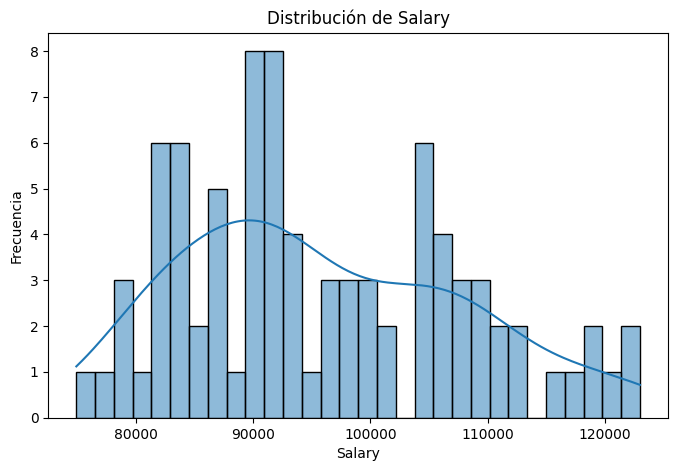

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(college_df["salary"], bins=30, kde=True)
plt.title("Distribución de Salary")
plt.xlabel("Salary")
plt.ylabel("Frecuencia")
plt.show()

**Interpretación:**

El histograma permite observar cómo se distribuyen los valores de salario. Se puede identificar en qué rangos se concentran la mayoría de los datos y si la distribución presenta algún tipo de sesgo. En este caso, si se observa una cola hacia la derecha, indica que existen algunos valores altos que elevan la distribución. Esto sugiere que hay cierta variabilidad en los salarios, con presencia de valores más elevados que el promedio.

Paso 2: Crea un diagrama de dispersión de salary vs cost, considerando lo siguiente: para cada punto elegirás un color que represente la localidad en la que está el salario y el costo de la educación. Por lo tanto el diagrama de dispersión debería tener puntos en 4 colores distintos. Discute lo que observas

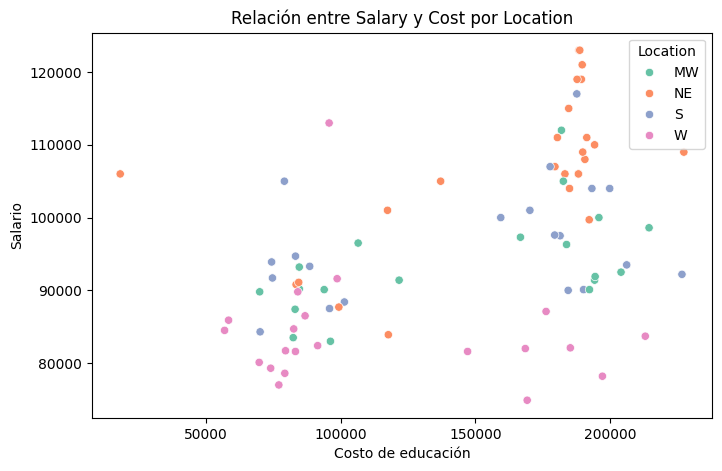

In [11]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=college_df,
    x="cost",
    y="salary",
    hue="location",
    palette="Set2"
)

plt.title("Relación entre Salary y Cost por Location")
plt.xlabel("Costo de educación")
plt.ylabel("Salario")
plt.legend(title="Location")
plt.show()

**Interpretación:**


El diagrama de dispersión permite analizar la relación entre el costo de la educación y el salario. Los colores representan las distintas ubicaciones, lo que facilita identificar si existen diferencias entre ellas. Se puede observar si hay una tendencia general (por ejemplo, a mayor costo mayor salario) y si ciertos grupos de localidades tienden a concentrarse en rangos específicos. Esto puede indicar que la ubicación influye tanto en el costo como en el salario.

Paso 3: Emplea un boxplot para saber si hay diferencias en los costos según la ubicación, es decir, con boxplot deberás analizar la distribución de cost por localidad. Discute lo que observas

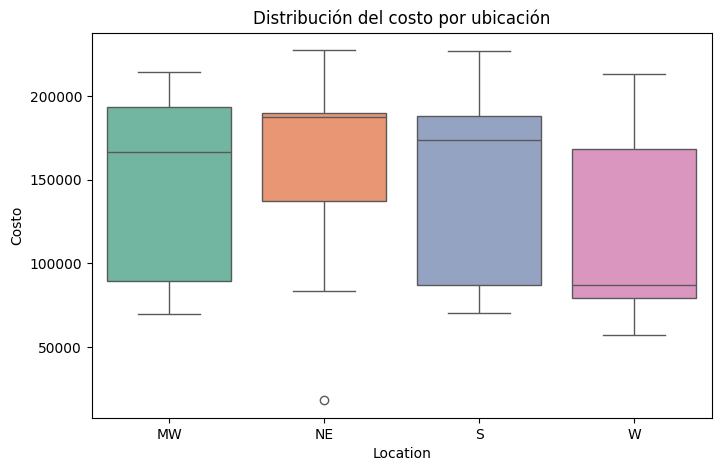

In [13]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=college_df,
    x="location",
    y="cost",
    hue="location",
    palette="Set2",
    legend=False
)

plt.title("Distribución del costo por ubicación")
plt.xlabel("Location")
plt.ylabel("Costo")
plt.show()

**Interpretación:**


El boxplot permite comparar la distribución de los costos entre diferentes ubicaciones. A través de este gráfico se pueden observar diferencias en la mediana, la dispersión y la presencia de valores atípicos en cada grupo. Si algunas localidades presentan cajas más altas o mayor variabilidad, esto indica que los costos en esas zonas tienden a ser más elevados o más dispersos. También es posible identificar si existen outliers que representen costos inusualmente altos o bajos.

# 3. Construcción del modelo de regresión

- Construye el modelo de regresión usando los datos de salario, costo y location. Recuerda que esta última debe ser en su versión codificada con one-hot encoding.
- Imprime los coeficientes e interpreta qué significan cuando se sustituyen valores en costo, y location (versión codificada). Si no recuerdas cómo se hace esta interpretación consulta los videos.


Paso 1: Definir variables X e y

In [14]:
X = college_encoded.drop(columns=["salary"])
y = college_encoded["salary"]

Paso 2: Crear y entrenar modelo

In [15]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)

LinearRegression()

Paso 3: Mostrar coeficientes

In [16]:
coef_df = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": model.coef_
})

coef_df

,Variable,Coeficiente
0,cost,0.060518
1,location_NE,12032.819692
2,location_S,2800.345026
3,location_W,-7721.420103


Paso 4: Mostrar intercepto

In [17]:
print("Intercepto:", model.intercept_)

Intercepto: 84988.71622754404


## Interpretación del modelo

El modelo de regresión lineal estima el salario en función del costo de la educación y la ubicación. La ecuación general del modelo es:

\[
salary = \beta_0 + \beta_1 (cost) + \beta_2 (location_1) + \beta_3 (location_2) + \dots
\]

### Donde:

- **β₀ (intercepto)** representa el salario base cuando el costo es cero y la ubicación corresponde a la categoría de referencia (la que se eliminó en el one-hot encoding).
- **β₁ (cost)** indica cuánto cambia el salario por cada unidad adicional en el costo de la educación.
- **β de location** indican cómo cambia el salario en comparación con la ubicación base.

---

## Interpretación del coeficiente de cost

Si el coeficiente de cost es positivo, significa que a mayor costo de la educación, el salario tiende a aumentar.  
Si es negativo, indica una relación inversa.

**Ejemplo:**

Si β₁ = 2, entonces:

Por cada aumento de 1 unidad en el costo, el salario aumenta en 2 unidades.

---

## Interpretación de las variables categóricas (location)

Las variables de ubicación están codificadas con one-hot encoding, por lo que:

- Cada coeficiente indica la diferencia en salario respecto a la categoría base.
- Si el coeficiente es positivo → esa ubicación tiene mayor salario promedio que la base.
- Si es negativo → tiene menor salario promedio.

**Ejemplo:**

Si location_urban = 5
Significa que en esa ubicación el salario es **5 unidades mayor** que en la ubicación base.

---

## Sustitución de valores (ejemplo práctico)

Supongamos:

- Intercepto = 10  
- cost = 2  
- location_urban = 5  

Para un caso donde:

- cost = 100  
- location_urban = 1  

El salario sería:

\[
salary = 10 + (2 \times 100) + (5 \times 1) = 215
\]

Esto muestra cómo cada variable contribuye al valor final del salario.

# 4. Análisis de Residuos

- Construyen una visualización de predicciones (salario estimado) vs valores reales (salario real).
- Crea una gráfica de los errores residuales. Discute lo que observas

# 5. Evalúa el modelo

- Calcula el MSE del modelo construido. Recuerda que usas el propio conjunto de datos (No hablamos nada de entrenamiento y test).
- Calcula el R² Score

Discute estos resultados obtenidos.

Paso 1: Predicciones

In [18]:
y_pred = model.predict(X)

Paso 2: Grafica real vs prediccion

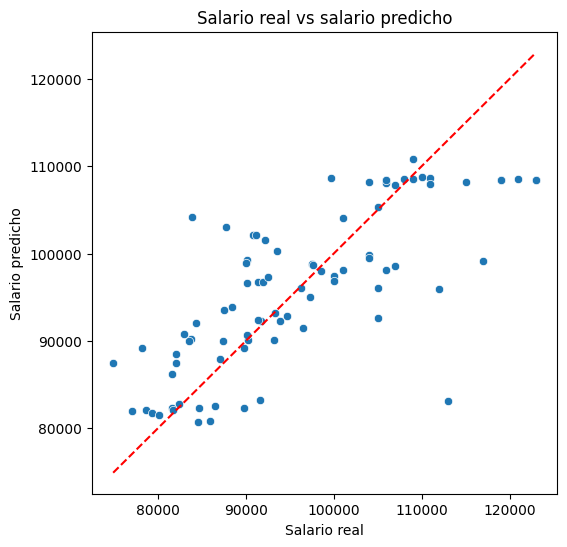

In [19]:
plt.figure(figsize=(6,6))

sns.scatterplot(x=y, y=y_pred)

plt.plot([y.min(), y.max()], [y.min(), y.max()], color="red", linestyle="--")

plt.title("Salario real vs salario predicho")
plt.xlabel("Salario real")
plt.ylabel("Salario predicho")

plt.show()

### Interpretación

La gráfica de valores reales vs predichos permite evaluar qué tan bien el modelo se ajusta a los datos.  
Si el modelo fuera perfecto, todos los puntos se ubicarían sobre la línea roja (y = x).

En este caso, mientras más cerca estén los puntos de la línea, mejor será la capacidad predictiva del modelo.  
Si se observa dispersión, indica que existen errores en las predicciones, lo cual es normal en modelos reales.

Paso 2: Calcular residuos

In [20]:
residuals = y - y_pred

Paso 3: Grafica de resiuos

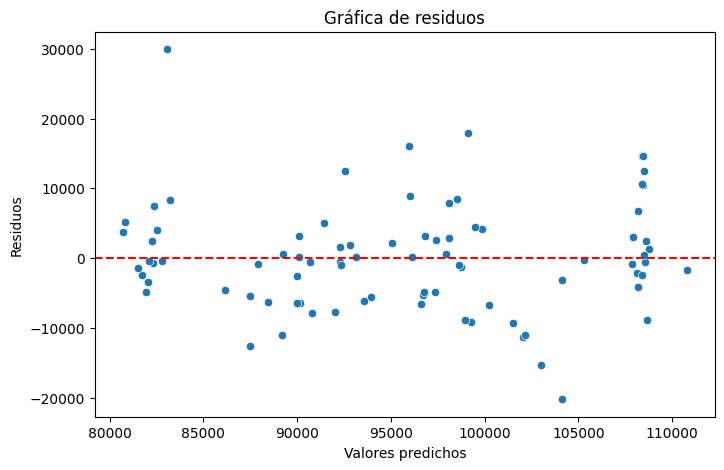

In [21]:
plt.figure(figsize=(8,5))

sns.scatterplot(x=y_pred, y=residuals)

plt.axhline(0, color="red", linestyle="--")

plt.title("Gráfica de residuos")
plt.xlabel("Valores predichos")
plt.ylabel("Residuos")

plt.show()

### Interpretación

La gráfica de residuos muestra la diferencia entre los valores reales y los valores predichos por el modelo.

Idealmente, los residuos deberían estar distribuidos de manera aleatoria alrededor de cero.  
Esto indica que el modelo no presenta sesgos sistemáticos.

Si se observan patrones (por ejemplo, forma de curva o agrupamientos), esto puede indicar que el modelo no está capturando completamente la relación entre las variables.

También es posible identificar valores atípicos si algunos residuos se alejan considerablemente del resto.

# 6. Realiza un análisis de varianza con stastmodel

Consulta esto aquí https://www.statsmodels.org/dev/examples/notebooks/generated/variance_components.html

Paso 1: Importar librerias

In [22]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

Paso 2: Crear modelo con formula

In [23]:
model_sm = smf.ols(
    formula="salary ~ cost + C(location)",
    data=college_df
).fit()

print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                 salary   R-squared:                       0.571
Model:                            OLS   Adj. R-squared:                  0.549
Method:                 Least Squares   F-statistic:                     26.57
Date:                Sun, 26 Apr 2026   Prob (F-statistic):           4.96e-14
Time:                        20:15:25   Log-Likelihood:                -882.12
No. Observations:                  85   AIC:                             1774.
Df Residuals:                      80   BIC:                             1786.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept          8.499e+04   3092.65

Paso 4: ANOVA

In [24]:
anova_table = sm.stats.anova_lm(model_sm, typ=2)
anova_table

,sum_sq,df,F,PR(>F)
C(location),4.071774e+09,3.0,21.121259,3.570975e-10
cost,7.878166e+08,1.0,12.259774,7.600629e-04
Residual,5.140823e+09,80.0,NaN,NaN


## Interpretación del ANOVA

El análisis de varianza (ANOVA) permite evaluar si las variables independientes tienen un efecto significativo sobre la variable dependiente (salary).

En la tabla ANOVA se observan principalmente:

- **sum_sq (suma de cuadrados):** mide la variabilidad explicada por cada variable.
- **F:** indica la relación entre la variabilidad explicada y la no explicada.
- **PR(>F) (p-valor):** indica si la variable es estadísticamente significativa.

### Interpretación de resultados:

- Si el p-valor es menor a 0.05, la variable se considera significativa.
- Si el p-valor es mayor a 0.05, la variable no tiene un efecto significativo sobre el salario.

### En este modelo:

- La variable **cost** permite evaluar si el costo de la educación influye en el salario.
- La variable **location** permite analizar si existen diferencias significativas en el salario según la ubicación.

Si ambas variables presentan p-valores bajos, se puede concluir que tienen un impacto significativo en el salario.